In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dynamic_routing_analysis import decoding_utils
# import dynamic_routing_analysis as dra
import npc_lims
import os

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
# %matplotlib inline
%matplotlib widget

In [50]:
#test on spontaneous activity
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/test_decoder_on_spontaneous_20251219_181131/" #test session

## results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/test_decoder_on_spontaneous_1/" 
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/test_decoder_on_spontaneous_2/" #all sessions
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/test_decoder_on_spontaneous_10_units_0/" #all sessions, 10 unit min

results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/decode_context_test_spont_500ms_10_units_loose_drift_0/"

session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

# all_session_list=(
#     session_table.filter(
#     pl.col('project')=="DynamicRouting",
#     pl.col('is_production'),
#     pl.col('is_annotated'),
#     pl.col('issues')==[],
#     # pl.col('is_good_behavior').eq(True),
#     )['session_id'].to_list()
#     )

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
}

for sel_session in dr_session_list:
    
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)

    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_good_behavior_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2')['session_id'].values

In [3]:
sel_session='742903_2024-10-22' #the golden session
# sel_session='670180_2023-07-27' #a templeton session
# sel_session='620263_2022-07-26' #templeton session w/o spontaneous

### task epoch results
predict_proba_single_session_pd = decoding_utils.load_single_session_decoder_confidence(
    results_path, sel_session, combine_multi_probe_rec=True).to_pandas()

### spontaneous activity results
predict_proba_with_repeats_single_session_spontaneous_pd = decoding_utils.load_single_session_decoder_confidence_spont_epoch(
    results_path, sel_session, combine_multi_probe_rec=True).to_pandas()


In [4]:
#get epochs
session_id=sel_session
epochs=pd.read_parquet(
    npc_lims.get_cache_path('epochs',session_id,version='any')
)
epochs

,start_time,stop_time,script_name,notes,interval_names,tags,session_idx,date,subject_id,session_id
id,,,,,,,,,,
0,44.79145,915.504433,RFMapping,,"[vis_rf_mapping_trials, aud_rf_mapping_trials]",[mapping],0,2024-10-22,742903,742903_2024-10-22
1,925.76399,1276.573301,OptoTagging,,[optotagging_trials],[optotagging],0,2024-10-22,742903,742903_2024-10-22
2,1286.79894,1889.936699,Spontaneous,,[spontaneous_trials],[spontaneous],0,2024-10-22,742903,742903_2024-10-22
3,1900.72890,2503.800740,SpontaneousRewards,,[spontaneous_rewards_trials],"[rewards, spontaneous]",0,2024-10-22,742903,742903_2024-10-22
4,2514.35961,6155.325601,DynamicRouting1,,"[trials, performance]","[task, rewards]",0,2024-10-22,742903,742903_2024-10-22
5,6166.13478,6769.256588,SpontaneousRewards,,[spontaneous_rewards_trials],"[rewards, spontaneous]",0,2024-10-22,742903,742903_2024-10-22
6,6779.73208,7382.853794,Spontaneous,,[spontaneous_trials],[spontaneous],0,2024-10-22,742903,742903_2024-10-22
7,7393.26257,7741.754331,OptoTagging,,[optotagging_trials],[optotagging],0,2024-10-22,742903,742903_2024-10-22


In [20]:
pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet').collect().to_pandas().columns

Index(['start_time', 'stop_time', 'block_index', 'n_trials', 'n_responses',
       'n_hits', 'n_contingent_rewards', 'hit_rate', 'false_alarm_rate',
       'catch_response_rate', 'rewarded_modality', 'is_first_block_aud',
       'cross_modality_dprime', 'signed_cross_modality_dprime', 'vis_dprime',
       'aud_dprime', 'vis_target_response_rate', 'vis_nontarget_response_rate',
       'aud_target_response_rate', 'aud_nontarget_response_rate',
       'session_idx', 'date', 'subject_id', 'session_id', 'id'],
      dtype='object')

In [74]:
sel_session='742903_2024-10-22'

In [75]:
# correlate each task block and spontaneous epoch separately

blockwise_corrs={
    'session_id': [],
    'structure_1': [],
    'structure_2': [],
    'bin_center': [],
    'unit_subsample': [],
    'plot_data_string': [],
    'block': [],
    'is_task_block': [],
    'is_spont_block': [],
    'r': [],
    'p': [],
    'n_trials': [],
    'time_start': [],
    'time_end': [],
    'block_cross_modality_dprime': [],
    'block_vis_dprime':[],
    'block_aud_dprime':[],
    'block_rewarded_modality': [],
    'block_n_responses': [],
    'block_n_contingent_rewards': [],
}

all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/trials.parquet').collect().to_pandas()
all_performance=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet').collect().to_pandas()
session_trials=all_trials.query('session_id==@sel_session')
session_performance=all_performance.query('session_id==@sel_session')

sel_structure_1='ORBl'
sel_structure_2='ACAd'

plot_data_string='predict_proba' # 'decision_function' or 'predict_proba'
sel_unit_subsample=10
sel_bin_center=-0.25
excl_instruction_trials=True

if sel_unit_subsample is None or sel_unit_subsample == 'all':
    structure_predict_proba_1=predict_proba_single_session_pd.query('structure==@sel_structure_1 and unit_subsample_size.isna() and bin_center==@sel_bin_center')
    structure_predict_proba_2=predict_proba_single_session_pd.query('structure==@sel_structure_2 and unit_subsample_size.isna() and bin_center==@sel_bin_center')
    structure_predict_proba_spont_1=predict_proba_with_repeats_single_session_spontaneous_pd.query('structure==@sel_structure_1 and unit_subsample_size.isna() and bin_center==@sel_bin_center')
    structure_predict_proba_spont_2=predict_proba_with_repeats_single_session_spontaneous_pd.query('structure==@sel_structure_2 and unit_subsample_size.isna() and bin_center==@sel_bin_center')
else:
    structure_predict_proba_1=predict_proba_single_session_pd.query('structure==@sel_structure_1 and unit_subsample_size==@sel_unit_subsample and bin_center==@sel_bin_center')
    structure_predict_proba_2=predict_proba_single_session_pd.query('structure==@sel_structure_2 and unit_subsample_size==@sel_unit_subsample and bin_center==@sel_bin_center')
    structure_predict_proba_spont_1=predict_proba_with_repeats_single_session_spontaneous_pd.query('structure==@sel_structure_1 and unit_subsample_size==@sel_unit_subsample and bin_center==@sel_bin_center')
    structure_predict_proba_spont_2=predict_proba_with_repeats_single_session_spontaneous_pd.query('structure==@sel_structure_2 and unit_subsample_size==@sel_unit_subsample and bin_center==@sel_bin_center')

#get task block indices
incl_trial_idx=structure_predict_proba_1['trial_index'].iloc[0]
session_trials=session_trials.query('trial_index in @incl_trial_idx').sort_values('trial_index').reset_index()
session_labels=session_trials['is_vis_rewarded'].values
instruction_trials=session_trials['is_instruction'].values
block_index=session_trials['block_index'].values

trial_times=structure_predict_proba_1['stim_start_time'].iloc[0]
total_n_units=structure_predict_proba_1['total_n_units'].iloc[0]

#get spont block indices
trial_times_spont=structure_predict_proba_spont_1['spont_trial_times'].iloc[0]
pretask_spont_index=trial_times_spont<trial_times[0]
pre_vs_post_task_spont_switch=np.where(pretask_spont_index)[0][-1]+1
spont_block_name_switches=np.where(np.diff((structure_predict_proba_spont_1['spont_epoch_name'].iloc[0]=='Spontaneous'))!=0)[0]+1

# spont_block_switch_inds=[spont_block_name_switches[0],pre_vs_post_task_spont_switch,spont_block_name_switches[1]]
spont_block_switch_inds=np.sort(np.unique(np.concatenate([spont_block_name_switches,[pre_vs_post_task_spont_switch]])))

spont_block_index=np.zeros(len(trial_times_spont),dtype=int)

if len(spont_block_switch_inds)==0:
    spont_block_index=np.zeros(len(trial_times_spont),dtype=int)
else:
    spont_block_index[:spont_block_switch_inds[0]]=0
    for i in range(1, len(spont_block_switch_inds)):
        spont_block_index[spont_block_switch_inds[i-1]:spont_block_switch_inds[i]]=i
    spont_block_index[spont_block_switch_inds[-1]:]=len(spont_block_switch_inds)

mean_task_predict_proba_1=np.nanmean(np.vstack(structure_predict_proba_1[plot_data_string].values),0)
mean_task_predict_proba_2=np.nanmean(np.vstack(structure_predict_proba_2[plot_data_string].values),0)
if excl_instruction_trials:
    mean_task_predict_proba_1[instruction_trials]=np.nan
    mean_task_predict_proba_2[instruction_trials]=np.nan

mean_spont_predict_proba_1=np.nanmean(np.vstack(structure_predict_proba_spont_1[f'{plot_data_string}_spont'].values),0)
mean_spont_predict_proba_2=np.nanmean(np.vstack(structure_predict_proba_spont_2[f'{plot_data_string}_spont'].values),0)


#calculate correlations for each block
for block in np.unique(block_index):
    block_trial_mask=block_index==block
    block_predict_proba_1=mean_task_predict_proba_1[block_trial_mask]
    block_predict_proba_2=mean_task_predict_proba_2[block_trial_mask]
    valid_mask=~np.isnan(block_predict_proba_1) & ~np.isnan(block_predict_proba_2)
    r,p=stats.pearsonr(block_predict_proba_1[valid_mask],block_predict_proba_2[valid_mask])

    blockwise_corrs['session_id'].append(sel_session)
    blockwise_corrs['structure_1'].append(sel_structure_1)
    blockwise_corrs['structure_2'].append(sel_structure_2)
    blockwise_corrs['bin_center'].append(sel_bin_center)
    blockwise_corrs['unit_subsample'].append(sel_unit_subsample)
    blockwise_corrs['plot_data_string'].append(plot_data_string)
    blockwise_corrs['block'].append(block)
    blockwise_corrs['is_task_block'].append(True)
    blockwise_corrs['is_spont_block'].append(False)
    blockwise_corrs['r'].append(r)
    blockwise_corrs['p'].append(p)
    blockwise_corrs['n_trials'].append(np.sum(block_trial_mask))
    blockwise_corrs['time_start'].append(trial_times[block_trial_mask][0])
    blockwise_corrs['time_end'].append(trial_times[block_trial_mask][-1])
    block_performance=session_performance.query('block_index==@block')
    blockwise_corrs['block_cross_modality_dprime'].append(block_performance['cross_modality_dprime'].values[0])
    blockwise_corrs['block_vis_dprime'].append(block_performance['vis_dprime'].values[0])
    blockwise_corrs['block_aud_dprime'].append(block_performance['aud_dprime'].values[0])
    blockwise_corrs['block_rewarded_modality'].append(block_performance['rewarded_modality'].values[0])
    blockwise_corrs['block_n_responses'].append(block_performance['n_responses'].values[0])
    blockwise_corrs['block_n_contingent_rewards'].append(block_performance['n_contingent_rewards'].values[0])

for block in np.unique(spont_block_index):
    block_trial_mask=np.where(spont_block_index==block)[0]
    block_predict_proba_1=mean_spont_predict_proba_1[block_trial_mask]
    block_predict_proba_2=mean_spont_predict_proba_2[block_trial_mask]
    valid_mask=~np.isnan(block_predict_proba_1) & ~np.isnan(block_predict_proba_2)
    r,p=stats.pearsonr(block_predict_proba_1[valid_mask],block_predict_proba_2[valid_mask])

    blockwise_corrs['session_id'].append(sel_session)
    blockwise_corrs['structure_1'].append(sel_structure_1)
    blockwise_corrs['structure_2'].append(sel_structure_2)
    blockwise_corrs['bin_center'].append(sel_bin_center)
    blockwise_corrs['unit_subsample'].append(sel_unit_subsample)
    blockwise_corrs['plot_data_string'].append(plot_data_string)
    blockwise_corrs['block'].append(block)
    blockwise_corrs['is_task_block'].append(False)
    blockwise_corrs['is_spont_block'].append(True)
    blockwise_corrs['r'].append(r)
    blockwise_corrs['p'].append(p)
    blockwise_corrs['n_trials'].append(np.sum(block_trial_mask))
    blockwise_corrs['time_start'].append(trial_times_spont[block_trial_mask][0])
    blockwise_corrs['time_end'].append(trial_times_spont[block_trial_mask][-1])

    blockwise_corrs['block_cross_modality_dprime'].append(np.nan)
    blockwise_corrs['block_vis_dprime'].append(np.nan)
    blockwise_corrs['block_aud_dprime'].append(np.nan)
    blockwise_corrs['block_rewarded_modality'].append(np.nan)
    blockwise_corrs['block_n_responses'].append(np.nan)
    blockwise_corrs['block_n_contingent_rewards'].append(np.nan)

blockwise_corrs_df=pd.DataFrame(blockwise_corrs)

In [43]:
# blockwise_corrs['block_n_contingent_rewards']
# blockwise_corrs['block_rewarded_modality']
# blockwise_corrs['block_n_responses']
# blockwise_corrs['block_n_contingent_rewards']

In [76]:
blockwise_corrs_df

,session_id,structure_1,structure_2,bin_center,unit_subsample,plot_data_string,block,is_task_block,is_spont_block,r,p,n_trials,time_start,time_end,block_cross_modality_dprime,block_vis_dprime,block_aud_dprime,block_rewarded_modality,block_n_responses,block_n_contingent_rewards
0,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,0,True,False,0.611544,1.323809e-09,86,2521.311880,3113.425150,3.612305,-0.051774,3.022234,aud,27.0,23.0
1,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,1,True,False,0.435929,2.724673e-05,91,3119.399435,3723.905720,2.555282,3.710650,0.000000,vis,28.0,24.0
2,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,2,True,False,0.644097,1.693303e-11,92,3731.291540,4333.799835,2.086724,0.022032,3.370542,aud,32.0,24.0
3,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,3,True,False,0.348149,1.173723e-03,89,4339.487960,4941.075160,2.787119,3.731438,-0.315110,vis,28.0,24.0
4,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,4,True,False,0.540501,7.797766e-08,91,4946.860780,5546.448960,2.686623,0.000000,2.246693,aud,29.0,23.0
5,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,5,True,False,-0.122538,2.668087e-01,89,5553.538190,6147.415740,0.779123,2.019139,0.000000,vis,18.0,13.0
6,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,0,False,True,0.310897,2.558188e-03,4186,1295.048940,1889.248940,NaN,NaN,NaN,NaN,NaN,NaN
7,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,1,False,True,0.296017,4.854154e-03,12104,1908.978900,2503.178900,NaN,NaN,NaN,NaN,NaN,NaN
8,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,2,False,True,-0.205686,5.314563e-02,20025,6174.384780,6768.584780,NaN,NaN,NaN,NaN,NaN,NaN
9,742903_2024-10-22,ORBl,ACAd,-0.25,10,predict_proba,3,False,True,-0.036738,7.280849e-01,29026,6787.982080,7382.182080,NaN,NaN,NaN,NaN,NaN,NaN


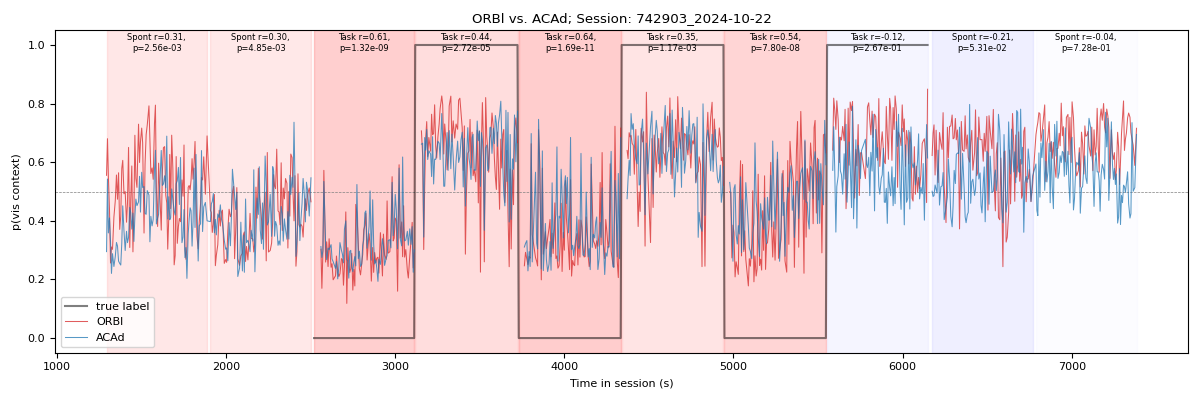

In [77]:
fig,ax=plt.subplots(figsize=(12,4))
if plot_data_string=='predict_proba':
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.5)
    ax.plot(trial_times, session_labels, color='black', alpha=0.5, label='true label')
    ax.set_ylabel('p(vis context)')
elif plot_data_string=='decision_function':
    ax.axhline(0.0, color='grey', linestyle='--', linewidth=0.5)
    ax.plot(trial_times, session_labels*4-2, color='black', alpha=0.5, label='true label')
    ax.set_ylabel('decision function')

ax.plot(trial_times, mean_task_predict_proba_1, color='tab:red', label=sel_structure_1, linewidth=0.75,alpha=0.75)
ax.plot(trial_times_spont[pretask_spont_index], 
        mean_spont_predict_proba_1[pretask_spont_index], 
        color='tab:red', linewidth=0.75,alpha=0.75)
ax.plot(trial_times_spont[~pretask_spont_index], 
mean_spont_predict_proba_1[~pretask_spont_index], 
        color='tab:red', linewidth=0.75,alpha=0.75)

ax.plot(trial_times, mean_task_predict_proba_2, color='tab:blue', label=sel_structure_2, linewidth=0.75,alpha=0.75)
ax.plot(trial_times_spont[pretask_spont_index], 
        mean_spont_predict_proba_2[pretask_spont_index], 
        color='tab:blue', linewidth=0.75,alpha=0.75)
ax.plot(trial_times_spont[~pretask_spont_index], 
mean_spont_predict_proba_2[~pretask_spont_index], 
        color='tab:blue', linewidth=0.75,alpha=0.75)

ax.set_xlabel('Time in session (s)')

ax.set_title(f'{sel_structure_1} vs. {sel_structure_2}; Session: {sel_session}')
ax.legend()

#add patches for each block indicating correlation value
for _,row in blockwise_corrs_df.iterrows():
    start=row['time_start']
    end=row['time_end']

    # scale colors between 0 and 1 based on r value, with r=0 as light grey and r=1 or -1 as dark color
    
    color=plt.cm.bwr((row['r']+1)/2) # map r value to color

    label_str=f"Task r={row['r']:.2f},\np={row['p']:.2e}" if row['is_task_block'] else f"Spont r={row['r']:.2f},\np={row['p']:.2e}"

    ax.axvspan(start, end, color=color, alpha=0.3,)
    ymin, ymax = ax.get_ylim()
    ax.text((start+end)/2, ymax*0.99, label_str, ha='center', va='top', fontsize=6,)

    
fig.tight_layout()

In [16]:
#load from saved files
loadpath=r'D:\decoding_results_from_CO\task_vs_spont_2026-04-22\task_predict_proba_by_session_10_units.parquet'
predict_proba_pd=pd.read_parquet(loadpath)

loadpath=r'D:\decoding_results_from_CO\task_vs_spont_2026-04-22\spont_predict_proba_by_session_10_units.parquet'
predict_proba_spont_pd=pd.read_parquet(loadpath)

In [17]:
# average some areas together per session:

simplfied_structure_grouping = {
    'VIS': ['VISp', 'VISa', 'VISal', 'VISam', 'VISl', 'VISli', 'VISp', 'VISpl', 'VISpm', 'VISpor'],
    'AUD': ['AUDp', 'AUDv', 'AUDd', 'AUDpo'],
    'AI': ['AIp', 'AIv', 'AId'],
    'RSP': ['RSPagl', 'RSPd', 'RSPv'],
    'HPF': ['CA1', 'CA2', 'CA3', 'DG', 'ENTl', 'ENTm', 'PAR', 'POST', 'PRE', 'SUB', 'ProS'],
    'OLF': ['OLF','AON','AOB','MOB','TT','DP','PIR'],
    'THALsm': ['VAL','VM','VPL','VPLpc','VPM','MGd','MGv','MGm','LGd'],
    'THALpm': ['LP','PO','POL','SGN','Eth', #
               'AV','AMd','AMv','AD','IAM','IAD','LD', #
               'IMD','MD','SMT','PR', #
               'PVT','PT','RE','Xi', #
               'RH','PCN','CM','CL','PF','PIL', #
               'RT', #
               'IGL','IntG','LGv','SubG', #
               'MH','LH' #
               ],
    'AMY': ['BLAp','CEAm'],
    'BG': ['GP','GPe','GPi','SNr','SNc','VTA'],
    'LS': ['LSc','LSr','LSv'],
}


In [51]:
# for each session, get the average predict proba for each structure in the simplified_structure_grouping, and delete the original structure-session row

# predict_proba_pd=predict_proba_pd[~predict_proba_pd['structure'].str.contains('SCzo|SCop|SCsg|SCiw|SCig|SCdw|SCdg|ECT1|ECT2/3|ECT4|ECT5|ECT6a|ECT6b')]


###TODO: fix unequal # trials for trial info and predict_proba!

use_first_spont_epoch_only=False
sel_bin_center=-0.25

new_predict_proba_pd = []

#round bin_center to 3 decimal places to avoid floating point issues
predict_proba_pd['bin_center']=predict_proba_pd['bin_center'].round(3)

all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/trials.parquet').collect().to_pandas()

#loop through each session
for sel_session in dr_good_behavior_list:
    print(f'Processing session {sel_session}')

    session_trials=all_trials.query('session_id==@sel_session')
    
    #get the table for the session
    predict_proba_pd_session=predict_proba_pd.query(f'session_id=="{sel_session}" and bin_center=={sel_bin_center}').reset_index(drop=True)
    predict_proba_spont_pd_session=predict_proba_spont_pd.query(f'session_id=="{sel_session}" and bin_center=={sel_bin_center}').reset_index(drop=True)
    
    if len(predict_proba_spont_pd_session)==0:
        print(f'no spontaneous data found for session {sel_session}; skipping')
        continue

    #option to limit to using only the first spont epoch for correlations
    if use_first_spont_epoch_only:
        for rr,row in predict_proba_spont_pd_session.iterrows():
            spont_epoch_name=row['spont_epoch_name']
            spont_block_change_inds=np.where(np.diff(spont_epoch_name=='Spontaneous'))[0]+1
            
            if len(spont_epoch_name)>len(row['trial_index']):
                spont_epoch_name=row['spont_epoch_name'][:len(row['trial_index'])]

            first_spont_block_inds=np.where(
                (spont_epoch_name=='Spontaneous')
                & (row['trial_index']<=spont_block_change_inds[0])
            )[0]

            predict_proba_spont_pd_session.at[rr,'decision_function_spont']=np.array(row['decision_function_spont'])[first_spont_block_inds]
            predict_proba_spont_pd_session.at[rr,'predict_proba_spont']=np.array(row['predict_proba_spont'])[first_spont_block_inds]
            predict_proba_spont_pd_session.at[rr,'trial_index']=np.array(row['trial_index'])[first_spont_block_inds]
            predict_proba_spont_pd_session.at[rr,'spont_trial_times']=np.array(row['spont_trial_times'])[first_spont_block_inds]
            predict_proba_spont_pd_session.at[rr,'spont_epoch_name']=np.array(row['spont_epoch_name'])[first_spont_block_inds]
            predict_proba_spont_pd_session.at[rr,'spont_trial_is_rewarded']=np.array(row['spont_trial_is_rewarded'])[first_spont_block_inds]
    else:
        for rr,row in predict_proba_spont_pd_session.iterrows():

            predict_proba_spont_pd_session.at[rr,'decision_function_spont']=np.array(row['decision_function_spont'])
            predict_proba_spont_pd_session.at[rr,'predict_proba_spont']=np.array(row['predict_proba_spont'])
            predict_proba_spont_pd_session.at[rr,'trial_index']=np.array(row['trial_index'])
            predict_proba_spont_pd_session.at[rr,'spont_trial_times']=np.array(row['spont_trial_times'])
            predict_proba_spont_pd_session.at[rr,'spont_epoch_name']=np.array(row['spont_epoch_name'])
            predict_proba_spont_pd_session.at[rr,'spont_trial_is_rewarded']=np.array(row['spont_trial_is_rewarded'])

    predict_proba_pd_session=pd.merge(
        predict_proba_pd_session, predict_proba_spont_pd_session, 
        on=['session_id','structure','unit_subsample_size','bin_center','time_aligned_to'],
        suffixes=['','_spont'])
    
    spont_is_pre_task=predict_proba_pd_session['spont_trial_times'].iloc[0]<session_trials['start_time'].iloc[0]

    predict_proba_pd_session['spont_is_pre_task']=[spont_is_pre_task]*len(predict_proba_pd_session)

    #loop through each structure in the simplified_structure_grouping
    for new_structure, old_structures in simplfied_structure_grouping.items():
        if len(old_structures) > 1:
            #get the rows for the old structures
            old_structure_rows = predict_proba_pd_session.query(f'structure in {old_structures}')

            #check if length of predict_proba for each rows match
            if old_structure_rows['predict_proba'].apply(len).nunique() > 1:
                print(f'Warning: predict_proba lengths do not match for session {sel_session} and structures {old_structures}. Skipping...')
                continue

            if not old_structure_rows.empty:
                new_structure_row = {
                    'session_id': sel_session,
                    'structure': new_structure,
                    'unit_subsample_size': old_structure_rows['unit_subsample_size'].iloc[0],
                    'bin_center': old_structure_rows['bin_center'].iloc[0],
                    'time_aligned_to': old_structure_rows['time_aligned_to'].iloc[0],
                    'balanced_accuracy_test': old_structure_rows['balanced_accuracy_test'].mean(),
                    'predict_proba': [old_structure_rows['predict_proba'].mean()],
                    'decision_function' : [old_structure_rows['decision_function'].mean()],
                    'trial_index': [old_structure_rows['trial_index'].iloc[0]],
                    'is_vis_rewarded': [old_structure_rows['is_vis_rewarded'].iloc[0]],
                    'stim_name': [old_structure_rows['stim_name'].iloc[0]],
                    'is_response': [old_structure_rows['is_response'].iloc[0]],
                    'predict_proba_spont': [old_structure_rows['predict_proba_spont'].mean()],
                    'decision_function_spont': [old_structure_rows['decision_function_spont'].mean()],
                    'spont_trial_times': [old_structure_rows['spont_trial_times'].iloc[0]],
                    'spont_epoch_name': [old_structure_rows['spont_epoch_name'].iloc[0]],
                    'spont_trial_is_rewarded': [old_structure_rows['spont_trial_is_rewarded'].iloc[0]],
                    'trial_index_spont': [old_structure_rows['trial_index_spont'].iloc[0]],
                    'spont_is_pre_task': [old_structure_rows['spont_is_pre_task'].iloc[0]]
                }

                predict_proba_pd_session = pd.concat([predict_proba_pd_session, pd.DataFrame(new_structure_row)], axis=0, ignore_index=True)
                
                #drop the old structure rows from the new_predict_proba_pd
                predict_proba_pd_session = predict_proba_pd_session.query(f'structure not in {old_structures}')


        else:
            #if only one old structure, just rename it to the new structure
            predict_proba_pd_session.loc[predict_proba_pd_session['session_id'] == sel_session, 'structure'] = old_structures[0]

    #update the new_predict_proba_pd with the session results
    # new_predict_proba_pd = pd.concat([new_predict_proba_pd, predict_proba_pd_session], axis=0, ignore_index=True)
    new_predict_proba_pd.append(predict_proba_pd_session)
    
    
new_predict_proba_pd = pd.concat(new_predict_proba_pd, axis=0, ignore_index=True)

Processing session 626791_2022-08-15
no spontaneous data found for session 626791_2022-08-15; skipping
Processing session 626791_2022-08-16
no spontaneous data found for session 626791_2022-08-16; skipping
Processing session 636766_2023-01-23
no spontaneous data found for session 636766_2023-01-23; skipping
Processing session 636766_2023-01-24
no spontaneous data found for session 636766_2023-01-24; skipping
Processing session 636766_2023-01-25
no spontaneous data found for session 636766_2023-01-25; skipping
Processing session 636766_2023-01-26
no spontaneous data found for session 636766_2023-01-26; skipping
Processing session 644864_2023-01-30
no spontaneous data found for session 644864_2023-01-30; skipping
Processing session 644864_2023-01-31
no spontaneous data found for session 644864_2023-01-31; skipping
Processing session 644864_2023-02-02
no spontaneous data found for session 644864_2023-02-02; skipping
Processing session 644866_2023-02-07
no spontaneous data found for sessio

In [116]:
#calculate across sessions

plot_data_string='predict_proba' # 'decision_function' or 'predict_proba'
sel_unit_subsample=10
sel_bin_center=-0.25
excl_instruction_trials=True

# correlate each task block and spontaneous epoch separately

blockwise_corrs={
    'session_id': [],
    'structure_1': [],
    'structure_2': [],
    'bin_center': [],
    'unit_subsample': [],
    'plot_data_string': [],
    'block': [],
    'is_task_block': [],
    'is_spont_block': [],
    'r': [],
    'p': [],
    'n_trials': [],
    'time_start': [],
    'time_end': [],
    'block_cross_modality_dprime': [],
    'block_vis_dprime':[],
    'block_aud_dprime':[],
    'block_rewarded_modality': [],
    'block_n_responses': [],
    'block_n_contingent_rewards': [],
}

all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/trials.parquet').collect().to_pandas()
all_performance=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet').collect().to_pandas()

for sel_session in dr_session_list:
    
    session_trials=all_trials.query('session_id==@sel_session')
    session_performance=all_performance.query('session_id==@sel_session')
    session_pd=new_predict_proba_pd.query('session_id==@sel_session')

    #get pairs of structures in this session
    session_structures=session_pd['structure'].unique()
    structure_pairs=[(s1,s2) for i,s1 in enumerate(session_structures) for s2 in session_structures[i+1:]]

    for pair in structure_pairs:
        sel_structure_1=pair[0]
        sel_structure_2=pair[1]

        if sel_unit_subsample is None or sel_unit_subsample == 'all':
            structure_predict_proba_1=session_pd.query('structure==@sel_structure_1 and unit_subsample_size.isna() and bin_center==@sel_bin_center')
            structure_predict_proba_2=session_pd.query('structure==@sel_structure_2 and unit_subsample_size.isna() and bin_center==@sel_bin_center')

        else:
            structure_predict_proba_1=session_pd.query('structure==@sel_structure_1 and unit_subsample_size==@sel_unit_subsample and bin_center==@sel_bin_center')
            structure_predict_proba_2=session_pd.query('structure==@sel_structure_2 and unit_subsample_size==@sel_unit_subsample and bin_center==@sel_bin_center')

        if len(structure_predict_proba_1)==0 or len(structure_predict_proba_2)==0:
            continue
        #get task block indices
        incl_trial_idx=structure_predict_proba_1['trial_index'].iloc[0]
        session_trials=session_trials.query('trial_index in @incl_trial_idx').sort_values('trial_index').reset_index(drop=True)
        session_labels=session_trials['is_vis_rewarded'].values
        instruction_trials=session_trials['is_instruction'].values
        block_index=session_trials['block_index'].values

        trial_times=structure_predict_proba_1['stim_start_time'].iloc[0]
        if np.isnan(trial_times).all():
            continue

        #get spont block indices
        trial_times_spont=structure_predict_proba_1['spont_trial_times'].iloc[0]
        pretask_spont_index=trial_times_spont<trial_times[0]
        pre_vs_post_task_spont_switch=np.where(pretask_spont_index)[0][-1]+1
        spont_block_name_switches=np.where(np.diff((structure_predict_proba_1['spont_epoch_name'].iloc[0]=='Spontaneous'))!=0)[0]+1

        # spont_block_switch_inds=[spont_block_name_switches[0],pre_vs_post_task_spont_switch,spont_block_name_switches[1]]
        spont_block_switch_inds=np.sort(np.unique(np.concatenate([spont_block_name_switches,[pre_vs_post_task_spont_switch]])))

        spont_block_index=np.zeros(len(trial_times_spont),dtype=int)

        if len(spont_block_switch_inds)==0:
            spont_block_index=np.zeros(len(trial_times_spont),dtype=int)
        else:
            spont_block_index[:spont_block_switch_inds[0]]=0
            for i in range(1, len(spont_block_switch_inds)):
                spont_block_index[spont_block_switch_inds[i-1]:spont_block_switch_inds[i]]=i
            spont_block_index[spont_block_switch_inds[-1]:]=len(spont_block_switch_inds)

        mean_task_predict_proba_1=np.nanmean(np.vstack(structure_predict_proba_1[plot_data_string].values),0)
        mean_task_predict_proba_2=np.nanmean(np.vstack(structure_predict_proba_2[plot_data_string].values),0)
        if excl_instruction_trials:
            mean_task_predict_proba_1[instruction_trials]=np.nan
            mean_task_predict_proba_2[instruction_trials]=np.nan

        mean_spont_predict_proba_1=np.nanmean(np.vstack(structure_predict_proba_1[f'{plot_data_string}_spont'].values),0)
        mean_spont_predict_proba_2=np.nanmean(np.vstack(structure_predict_proba_2[f'{plot_data_string}_spont'].values),0)

        if len(trial_times_spont)>len(mean_spont_predict_proba_1):
            trial_times_spont=trial_times_spont[:len(mean_spont_predict_proba_1)]
            spont_block_index=spont_block_index[:len(mean_spont_predict_proba_1)]
        elif len(trial_times_spont)<len(mean_spont_predict_proba_1):
            mean_spont_predict_proba_1=mean_spont_predict_proba_1[:len(trial_times_spont)]
            mean_spont_predict_proba_2=mean_spont_predict_proba_2[:len(trial_times_spont)]
            spont_block_index=spont_block_index[:len(trial_times_spont)]

        #calculate correlations for each block
        for block in np.unique(block_index):
            block_trial_mask=block_index==block
            block_predict_proba_1=mean_task_predict_proba_1[block_trial_mask]
            block_predict_proba_2=mean_task_predict_proba_2[block_trial_mask]
            valid_mask=~np.isnan(block_predict_proba_1) & ~np.isnan(block_predict_proba_2)
            r,p=stats.pearsonr(block_predict_proba_1[valid_mask],block_predict_proba_2[valid_mask])

            blockwise_corrs['session_id'].append(sel_session)
            blockwise_corrs['structure_1'].append(sel_structure_1)
            blockwise_corrs['structure_2'].append(sel_structure_2)
            blockwise_corrs['bin_center'].append(sel_bin_center)
            blockwise_corrs['unit_subsample'].append(sel_unit_subsample)
            blockwise_corrs['plot_data_string'].append(plot_data_string)
            blockwise_corrs['block'].append(block)
            blockwise_corrs['is_task_block'].append(True)
            blockwise_corrs['is_spont_block'].append(False)
            blockwise_corrs['r'].append(r)
            blockwise_corrs['p'].append(p)
            blockwise_corrs['n_trials'].append(np.sum(block_trial_mask))
            blockwise_corrs['time_start'].append(trial_times[block_trial_mask][0])
            blockwise_corrs['time_end'].append(trial_times[block_trial_mask][-1])
            block_performance=session_performance.query('block_index==@block')
            blockwise_corrs['block_cross_modality_dprime'].append(block_performance['cross_modality_dprime'].values[0])
            blockwise_corrs['block_vis_dprime'].append(block_performance['vis_dprime'].values[0])
            blockwise_corrs['block_aud_dprime'].append(block_performance['aud_dprime'].values[0])
            blockwise_corrs['block_rewarded_modality'].append(block_performance['rewarded_modality'].values[0])
            blockwise_corrs['block_n_responses'].append(block_performance['n_responses'].values[0])
            blockwise_corrs['block_n_contingent_rewards'].append(block_performance['n_contingent_rewards'].values[0])

        for block in np.unique(spont_block_index):
            block_trial_mask=block_index==block
            if len(block_trial_mask)>=len(mean_spont_predict_proba_1):
                block_trial_mask=block_trial_mask[:len(mean_spont_predict_proba_1)]
            if len(block_trial_mask)==0:
                continue
            block_predict_proba_1=mean_spont_predict_proba_1[block_trial_mask]
            block_predict_proba_2=mean_spont_predict_proba_2[block_trial_mask]
            valid_mask=~np.isnan(block_predict_proba_1) & ~np.isnan(block_predict_proba_2)
            r,p=stats.pearsonr(block_predict_proba_1[valid_mask],block_predict_proba_2[valid_mask])

            blockwise_corrs['session_id'].append(sel_session)
            blockwise_corrs['structure_1'].append(sel_structure_1)
            blockwise_corrs['structure_2'].append(sel_structure_2)
            blockwise_corrs['bin_center'].append(sel_bin_center)
            blockwise_corrs['unit_subsample'].append(sel_unit_subsample)
            blockwise_corrs['plot_data_string'].append(plot_data_string)
            blockwise_corrs['block'].append(block)
            blockwise_corrs['is_task_block'].append(False)
            blockwise_corrs['is_spont_block'].append(True)
            blockwise_corrs['r'].append(r)
            blockwise_corrs['p'].append(p)
            blockwise_corrs['n_trials'].append(np.sum(block_trial_mask))
            blockwise_corrs['time_start'].append(trial_times_spont[block_trial_mask][0])
            blockwise_corrs['time_end'].append(trial_times_spont[block_trial_mask][-1])

            blockwise_corrs['block_cross_modality_dprime'].append(np.nan)
            blockwise_corrs['block_vis_dprime'].append(np.nan)
            blockwise_corrs['block_aud_dprime'].append(np.nan)
            blockwise_corrs['block_rewarded_modality'].append(np.nan)
            blockwise_corrs['block_n_responses'].append(np.nan)
            blockwise_corrs['block_n_contingent_rewards'].append(np.nan)

    print(f'Finished processing session {sel_session}')

blockwise_corrs_df=pd.DataFrame(blockwise_corrs)

Finished processing session 626791_2022-08-15
Finished processing session 626791_2022-08-16
Finished processing session 626791_2022-08-17
Finished processing session 636766_2023-01-23
Finished processing session 636766_2023-01-24
Finished processing session 636766_2023-01-25
Finished processing session 636766_2023-01-26
Finished processing session 644864_2023-01-30
Finished processing session 644864_2023-01-31
Finished processing session 644864_2023-02-02
Finished processing session 644866_2023-02-07
Finished processing session 644866_2023-02-08
Finished processing session 644866_2023-02-09
Finished processing session 644866_2023-02-10
Finished processing session 649943_2023-02-13
Finished processing session 649943_2023-02-14
Finished processing session 649943_2023-02-15
Finished processing session 649943_2023-02-16
Finished processing session 644867_2023-02-20
Finished processing session 644867_2023-02-22
Finished processing session 644867_2023-02-23
Finished processing session 660023

In [117]:
blockwise_corrs_df.to_parquet(r'D:\decoding_results_from_CO\blockwise_correlations_across_areas_2026-05-15\blockwise_correlations_10_unit_subsample.parquet')

In [118]:
blockwise_corrs_df

,session_id,structure_1,structure_2,bin_center,unit_subsample,plot_data_string,block,is_task_block,is_spont_block,r,p,n_trials,time_start,time_end,block_cross_modality_dprime,block_vis_dprime,block_aud_dprime,block_rewarded_modality,block_n_responses,block_n_contingent_rewards
0,660023_2023-08-09,MOp,MRN,-0.25,10,predict_proba,0,True,False,-0.060810,0.580364,90,16633.999040,17229.238993,2.179410,0.000000,0.772197,aud,52.0,25.0
1,660023_2023-08-09,MOp,MRN,-0.25,10,predict_proba,1,True,False,0.090071,0.455062,76,17234.760340,17836.134256,3.202512,2.291317,-0.712382,vis,27.0,20.0
2,660023_2023-08-09,MOp,MRN,-0.25,10,predict_proba,2,True,False,0.328722,0.002733,86,17842.105050,18444.674340,1.375637,-0.344713,1.334283,aud,47.0,22.0
3,660023_2023-08-09,MOp,MRN,-0.25,10,predict_proba,3,True,False,0.204675,0.072250,83,18450.579305,19047.399743,3.201393,3.131102,-1.578468,vis,32.0,21.0
4,660023_2023-08-09,MOp,MRN,-0.25,10,predict_proba,4,True,False,0.058505,0.599327,88,19053.370324,19650.851945,1.991971,-0.045458,0.475860,aud,40.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38595,759434_2025-02-07,TTd,LS,-0.25,10,predict_proba,5,True,False,-0.244422,0.025045,89,5194.835885,5790.835230,3.681688,3.996798,0.000000,vis,25.0,24.0
38596,759434_2025-02-07,TTd,LS,-0.25,10,predict_proba,0,False,True,-0.075609,0.476269,91,932.410367,1516.360367,NaN,NaN,NaN,NaN,NaN,NaN
38597,759434_2025-02-07,TTd,LS,-0.25,10,predict_proba,1,False,True,-0.114498,0.288134,88,1522.543700,2129.622617,NaN,NaN,NaN,NaN,NaN,NaN
38598,759434_2025-02-07,TTd,LS,-0.25,10,predict_proba,2,False,True,0.079380,0.454489,91,2135.805950,6434.063483,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'r=0.29, p=9.31e-05')

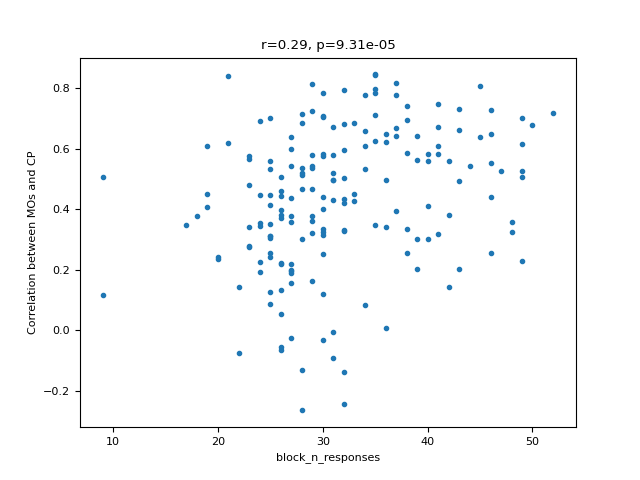

In [132]:
s1='MOs'
s2='CP'
sel_var='block_n_responses'
corr=blockwise_corrs_df.query('is_task_block and structure_1==@s1 and structure_2==@s2')['r'].values
variable=blockwise_corrs_df.query('is_task_block and structure_1==@s1 and structure_2==@s2')[sel_var].values

if len(corr)==0 and len(variable)==0:
    corr=blockwise_corrs_df.query('is_task_block and structure_1==@s2 and structure_2==@s1')['r'].values
    variable=blockwise_corrs_df.query('is_task_block and structure_1==@s2 and structure_2==@s1')[sel_var].values

r,p=stats.pearsonr(corr,variable)

fig,ax=plt.subplots()
ax.plot(variable,corr,'.')
ax.set_xlabel(sel_var)
ax.set_ylabel(f'Correlation between {s1} and {s2}')
ax.set_title(f'r={r:.2f}, p={p:.2e}')

In [156]:
#for each session

sel_session='742903_2024-10-22'

session_corrs=blockwise_corrs_df.query('session_id==@sel_session')

session_corrs.loc[session_corrs['is_spont_block'],'block']=session_corrs.loc[session_corrs['is_spont_block'],'block']+6

blockwise_correlations={
    'block': [],
    'is_task_block': [],
    'is_spont_block': [],
    'structure_list': [],
    'correlation_matrix': [],
    'correlation_vector': [],
}

unique_structures=session_corrs['structure_1'].unique()
structure_combos=[(s1,s2) for i,s1 in enumerate(unique_structures) for s2 in unique_structures[i+1:]]

#for each block, build a correlation matrix between areas
for block in session_corrs['block'].unique():
    block_corrs=session_corrs.query('block==@block')
    #build correlation matrix with areas as rows and columns, and r values as values
    corr_matrix=pd.DataFrame(np.nan, index=unique_structures, columns=unique_structures)
    corr_vect=[]
    for sel_structure, other_structure in structure_combos:
        r_value=block_corrs.query('(structure_1==@sel_structure and structure_2==@other_structure) or (structure_1==@other_structure and structure_2==@sel_structure)')['r'].values
        if len(r_value)>0:
            corr_matrix.loc[sel_structure,other_structure]=r_value[0]
            corr_vect.append(r_value[0])
    corr_vect=np.array(corr_vect)
    blockwise_correlations['block'].append(block)
    blockwise_correlations['is_task_block'].append(block_corrs['is_task_block'].iloc[0])
    blockwise_correlations['is_spont_block'].append(block_corrs['is_spont_block'].iloc[0])
    blockwise_correlations['structure_list'].append(unique_structures)
    blockwise_correlations['correlation_matrix'].append(corr_matrix)
    blockwise_correlations['correlation_vector'].append(corr_vect)

blockwise_correlations=pd.DataFrame(blockwise_correlations)

#then correlate the correlation matrices across blocks

#are within-epoch (task vs task or spont vs spont) correlation matrices more similar than cross-epoch (task vs spont)?

#good behavior blocks more correlated than bad behavior blocks?

#pre-task spont more correlated than pre vs post task?

#save each of these comparisons per session

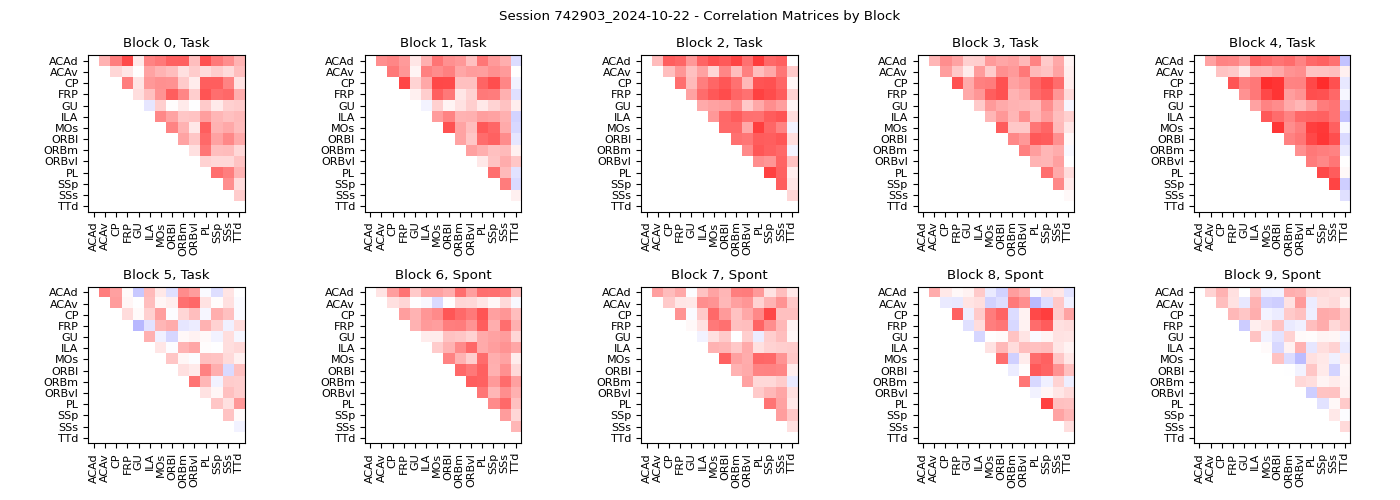

In [155]:
fig,ax=plt.subplots(2,5,figsize=(14,5))
ax=ax.flatten()
for rr,result in blockwise_correlations.iterrows():

    im=ax[rr].imshow(result['correlation_matrix'], vmin=-1, vmax=1, cmap='bwr')
    ax[rr].set_xticks(np.arange(len(result['structure_list'])))
    ax[rr].set_yticks(np.arange(len(result['structure_list'])))
    ax[rr].set_xticklabels(result['structure_list'], rotation=90)
    ax[rr].set_yticklabels(result['structure_list'])
    ax[rr].set_title(f"Block {result['block']}, {'Task' if result['is_task_block'] else 'Spont'}")

fig.suptitle(f'Session {sel_session} - Correlation Matrices by Block')
fig.tight_layout()

In [170]:
# within_task_combos

r,p=stats.pearsonr(
    blockwise_correlations.iloc[2]['correlation_vector'], 
    blockwise_correlations.iloc[8]['correlation_vector']
)
r

0.36947388539676823